In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

In [ ]:
import pandas as pd
df=pd.read_excel('/content/drive/MyDrive/Bank-Clients2.xlsx')

In [ ]:
df

,Id,age,job,marital,education,housing,loan
0,1001,NaN,working,married,primary,yes,no
1,1002,NaN,NaN,single,secondary,yes,no
2,1003,NaN,working,married,secondary,yes,yes
3,1004,47.0,NaN,married,primary,yes,no
4,1005,33.0,working,single,primary,no,no
...,...,...,...,...,...,...,...
417,1418,43.0,working,married,secondary,yes,no
418,1419,52.0,working,NaN,primary,NaN,yes
419,1420,33.0,NaN,married,NaN,yes,no
420,1421,49.0,retired,single,primary,yes,NaN


In [ ]:
df.columns

Index(['Id', 'age', 'job', 'marital', 'education', 'housing', 'loan'], dtype='object')

In [ ]:
df.isna().sum()

Id            0
age          43
job          58
marital      59
education    55
housing      47
loan         46
dtype: int64

In [ ]:
df.isna().sum().sum()

308

***Data cleaning***




In [ ]:
df.head()

,Id,age,job,marital,education,housing,loan
0,1001,NaN,working,married,primary,yes,no
1,1002,NaN,NaN,single,secondary,yes,no
2,1003,NaN,working,married,secondary,yes,yes
3,1004,47.0,NaN,married,primary,yes,no
4,1005,33.0,working,single,primary,no,no


In [ ]:
df.tail()

,Id,age,job,marital,education,housing,loan
417,1418,43.0,working,married,secondary,yes,no
418,1419,52.0,working,NaN,primary,NaN,yes
419,1420,33.0,NaN,married,NaN,yes,no
420,1421,49.0,retired,single,primary,yes,NaN
421,1422,32.0,retired,single,primary,yes,no


In [ ]:
new_df = df.copy()
new_df.shape

(422, 7)

In [ ]:
new_df['age'].fillna(df['age'].mean() , inplace= True)
new_df['age'].isna().sum()

0

In [ ]:
new_df['Id'].fillna(df['Id'].mode() , inplace= True)
new_df['Id'].isna().sum()

0

In [ ]:
#it replce nullvalues wit te mmostly occurin value
new_df['job'].fillna(df['job'].value_counts().index[0], inplace= True)
new_df['job'].isna().sum()

0

In [ ]:
new_df['marital'].fillna(df['marital'].value_counts().index[0], inplace= True)
new_df['marital'].isna().sum()

0

In [ ]:
new_df['education'].fillna(df['education'].value_counts().index[0], inplace= True)
new_df['education'].isna().sum()

0

In [ ]:
new_df['housing'].fillna(df['housing'].value_counts().index[0], inplace= True)
new_df['housing'].isna().sum()

0

In [ ]:
new_df['loan'].fillna(df['loan'].value_counts().index[0], inplace= True)
new_df['loan'].isna().sum()

0

In [ ]:
new_df_num = new_df.select_dtypes(exclude='object')
new_df_num

,Id,age
0,1001,44.350923
1,1002,44.350923
2,1003,44.350923
3,1004,47.000000
4,1005,33.000000
...,...,...
417,1418,43.000000
418,1419,52.000000
419,1420,33.000000
420,1421,49.000000


In [ ]:
new_df_num.shape

(422, 2)

In [ ]:
new_df_num.corr()  #to give the correlation martix between different numerical values

,Id,age
Id,1.0000,-0.1203
age,-0.1203,1.0000


***Data preprocessing***

In [ ]:
new_df['job'].unique()

array(['working', 'retired'], dtype=object)

In [ ]:
new_df['job'].value_counts()

job
working    276
retired    146
Name: count, dtype: int64

In [ ]:
import numpy as np
new_df['job'] = np.where(df['job'].str.contains('working'), 1, 0)
new_df.head()

,Id,age,job,marital,education,housing,loan
0,1001,44.350923,1,married,primary,yes,no
1,1002,44.350923,1,single,secondary,yes,no
2,1003,44.350923,1,married,secondary,yes,yes
3,1004,47.000000,1,married,primary,yes,no
4,1005,33.000000,1,single,primary,no,no


In [ ]:
new_df['marital'].unique()
new_df['marital'].value_counts()

marital
married    291
single     131
Name: count, dtype: int64

In [ ]:
new_df['marital'] = np.where(df['marital'].str.contains('single'), 1, 0)
new_df.head()

,Id,age,job,marital,education,housing,loan
0,1001,44.350923,1,0,primary,yes,no
1,1002,44.350923,1,1,secondary,yes,no
2,1003,44.350923,1,0,secondary,yes,yes
3,1004,47.000000,1,0,primary,yes,no
4,1005,33.000000,1,1,primary,no,no


In [ ]:
new_df['education'].unique()
new_df['education'].value_counts()

education
secondary    261
primary      160
working        1
Name: count, dtype: int64

In [ ]:
new_df['education'].replace(['working'] , np.nan, inplace = True)

In [ ]:
new_df['education'].fillna( method="ffill")

0        primary
1      secondary
2      secondary
3        primary
4        primary
         ...    
417    secondary
418      primary
419    secondary
420      primary
421      primary
Name: education, Length: 422, dtype: object

In [ ]:
new_df['education'] = np.where(df['education'].str.contains('primary'), 1, 0)
new_df.head()

,Id,age,job,marital,education,housing,loan
0,1001,44.350923,1,0,1,yes,no
1,1002,44.350923,1,1,0,yes,no
2,1003,44.350923,1,0,0,yes,yes
3,1004,47.000000,1,0,1,yes,no
4,1005,33.000000,1,1,1,no,no


In [ ]:
new_df['housing'] = np.where(df['housing'].str.contains('yes'), 1, 0)
new_df.head()

,Id,age,job,marital,education,housing,loan
0,1001,44.350923,1,0,1,1,no
1,1002,44.350923,1,1,0,1,no
2,1003,44.350923,1,0,0,1,yes
3,1004,47.000000,1,0,1,1,no
4,1005,33.000000,1,1,1,0,no


In [ ]:
new_df['loan'] = np.where(df['loan'].str.contains('yes'), 1, 0)
new_df.head()

,Id,age,job,marital,education,housing,loan
0,1001,44.350923,1,0,1,1,0
1,1002,44.350923,1,1,0,1,0
2,1003,44.350923,1,0,0,1,1
3,1004,47.000000,1,0,1,1,0
4,1005,33.000000,1,1,1,0,0


In [ ]:
new_df.isna().sum().sum()

0

In [ ]:
len(new_df)

422

In [ ]:
df_tt = new_df.copy()
df_tt.tail()

,Id,age,job,marital,education,housing,loan
417,1418,43.0,1,0,0,1,0
418,1419,52.0,1,1,1,1,1
419,1420,33.0,1,0,1,1,0
420,1421,49.0,0,1,1,1,1
421,1422,32.0,0,1,1,1,0


In [ ]:
from sklearn.model_selection import train_test_split
# Split dataset into training set and test set
#split dataset in features and target variable
feature_cols = ['Id', 'job', 'age','education','marital','housing']
X = df_tt[feature_cols] # Features
y = df_tt.loan # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

In [ ]:
X.head()

,Id,job,age,education,marital,housing
0,1001,1,44.350923,1,0,1
1,1002,1,44.350923,0,1,1
2,1003,1,44.350923,0,0,1
3,1004,1,47.000000,1,0,1
4,1005,1,33.000000,1,1,0


In [ ]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: loan, dtype: int64

In [ ]:
X.tail()

,Id,job,age,education,marital,housing
417,1418,1,43.0,0,0,1
418,1419,1,52.0,1,1,1
419,1420,1,33.0,1,0,1
420,1421,0,49.0,1,1,1
421,1422,0,32.0,1,1,1


In [ ]:
y.tail()

417    0
418    1
419    0
420    1
421    0
Name: loan, dtype: int64

In [ ]:
X_train.shape

(295, 6)

In [ ]:
X_test.corr()

,Id,job,age,education,marital,housing
Id,1.000000,0.154557,-0.035456,-0.019953,-0.070686,-0.071524
job,0.154557,1.000000,-0.127486,-0.164310,-0.001792,-0.053774
age,-0.035456,-0.127486,1.000000,0.049892,-0.292419,0.030785
education,-0.019953,-0.164310,0.049892,1.000000,0.022106,-0.005567
marital,-0.070686,-0.001792,-0.292419,0.022106,1.000000,0.126989
housing,-0.071524,-0.053774,0.030785,-0.005567,0.126989,1.000000


In [ ]:
y_test.shape

(127,)

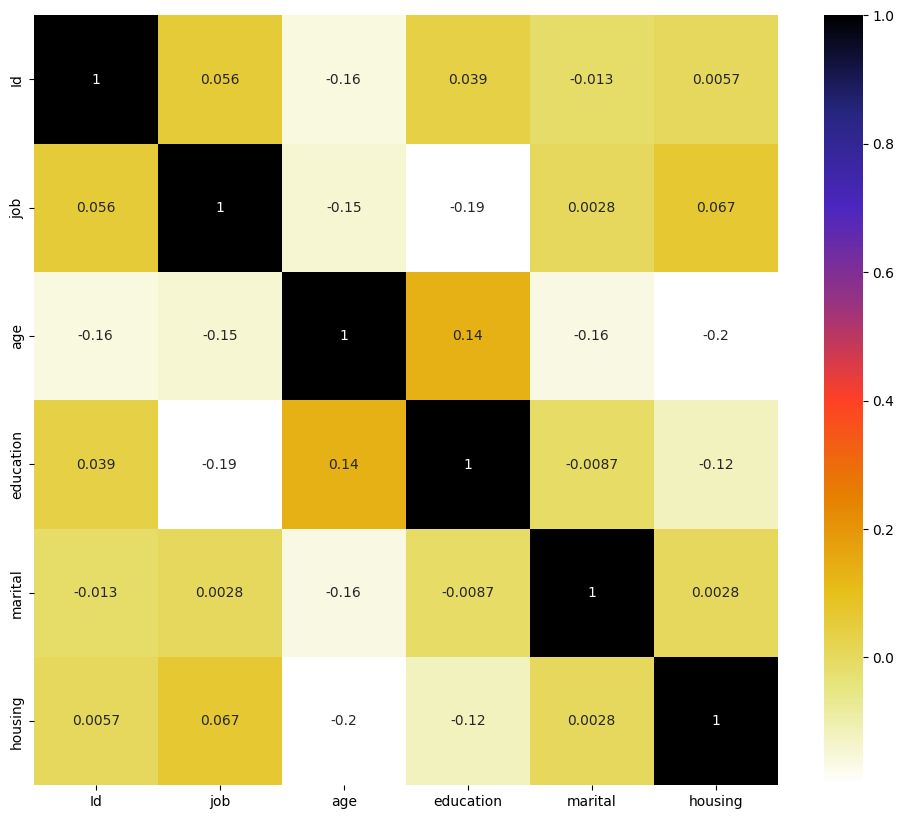

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
cor = X_train.corr()
sns.heatmap(cor, annot = True , cmap=plt.cm.CMRmap_r)
plt.show()

In [ ]:
from sklearn.feature_selection import chi2
f_p_values = chi2(X_train , y_train)
f_p_values

(array([15.77779833,  0.41772729,  0.05372991,  1.580684  ,  0.0572633 ,
         0.10898665]),
 array([7.12335184e-05, 5.18073268e-01, 8.16695585e-01, 2.08662197e-01,
        8.10874891e-01, 7.41300779e-01]))

In [ ]:
import pandas as pd
p_values=pd.Series(f_p_values[1])
p_values.index=X_train.columns
p_values

Id           0.000071
job          0.518073
age          0.816696
education    0.208662
marital      0.810875
housing      0.741301
dtype: float64

In [ ]:
p_values.sort_index(ascending=False)

marital      0.810875
job          0.518073
housing      0.741301
education    0.208662
age          0.816696
Id           0.000071
dtype: float64

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_ss=pd.DataFrame(scaler.fit_transform(df_tt[['job','education']]),columns=[['job','education']])
print(df_ss.head())

        job education
0  0.727314  0.981219
1  0.727314 -1.019140
2  0.727314 -1.019140
3  0.727314  0.981219
4  0.727314  0.981219


In [ ]:
from sklearn.preprocessing import MinMaxScaler
min_max=MinMaxScaler()
df_mm=pd.DataFrame(min_max.fit_transform(df_tt[['age','marital']]),columns=[['age','marital']])
print(df_mm.head())
print(df_mm.shape)

        age marital
0  0.573101     0.0
1  0.573101     1.0
2  0.573101     0.0
3  0.641026     0.0
4  0.282051     1.0
(422, 2)


***CLASSIFIER***

In [ ]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

In [ ]:
from sklearn import metrics

# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7795275590551181


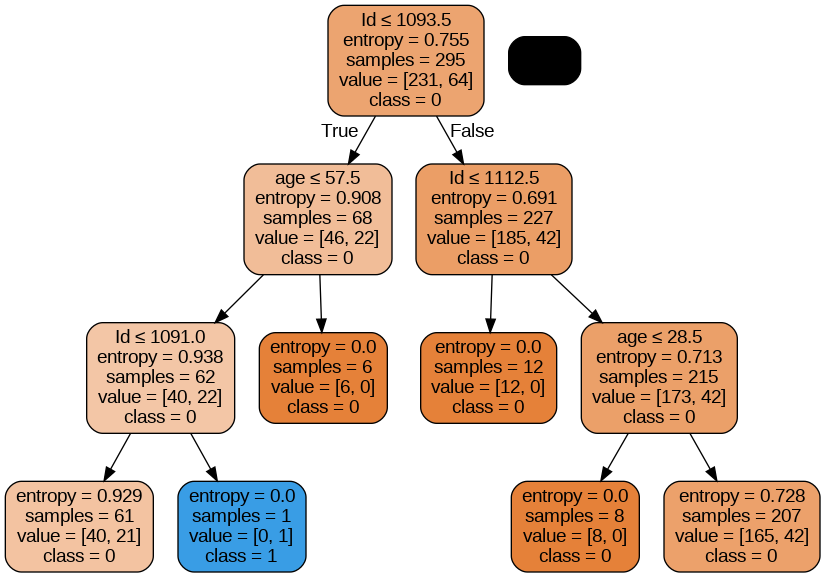

In [ ]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('client.png')
Image(graph.create_png())

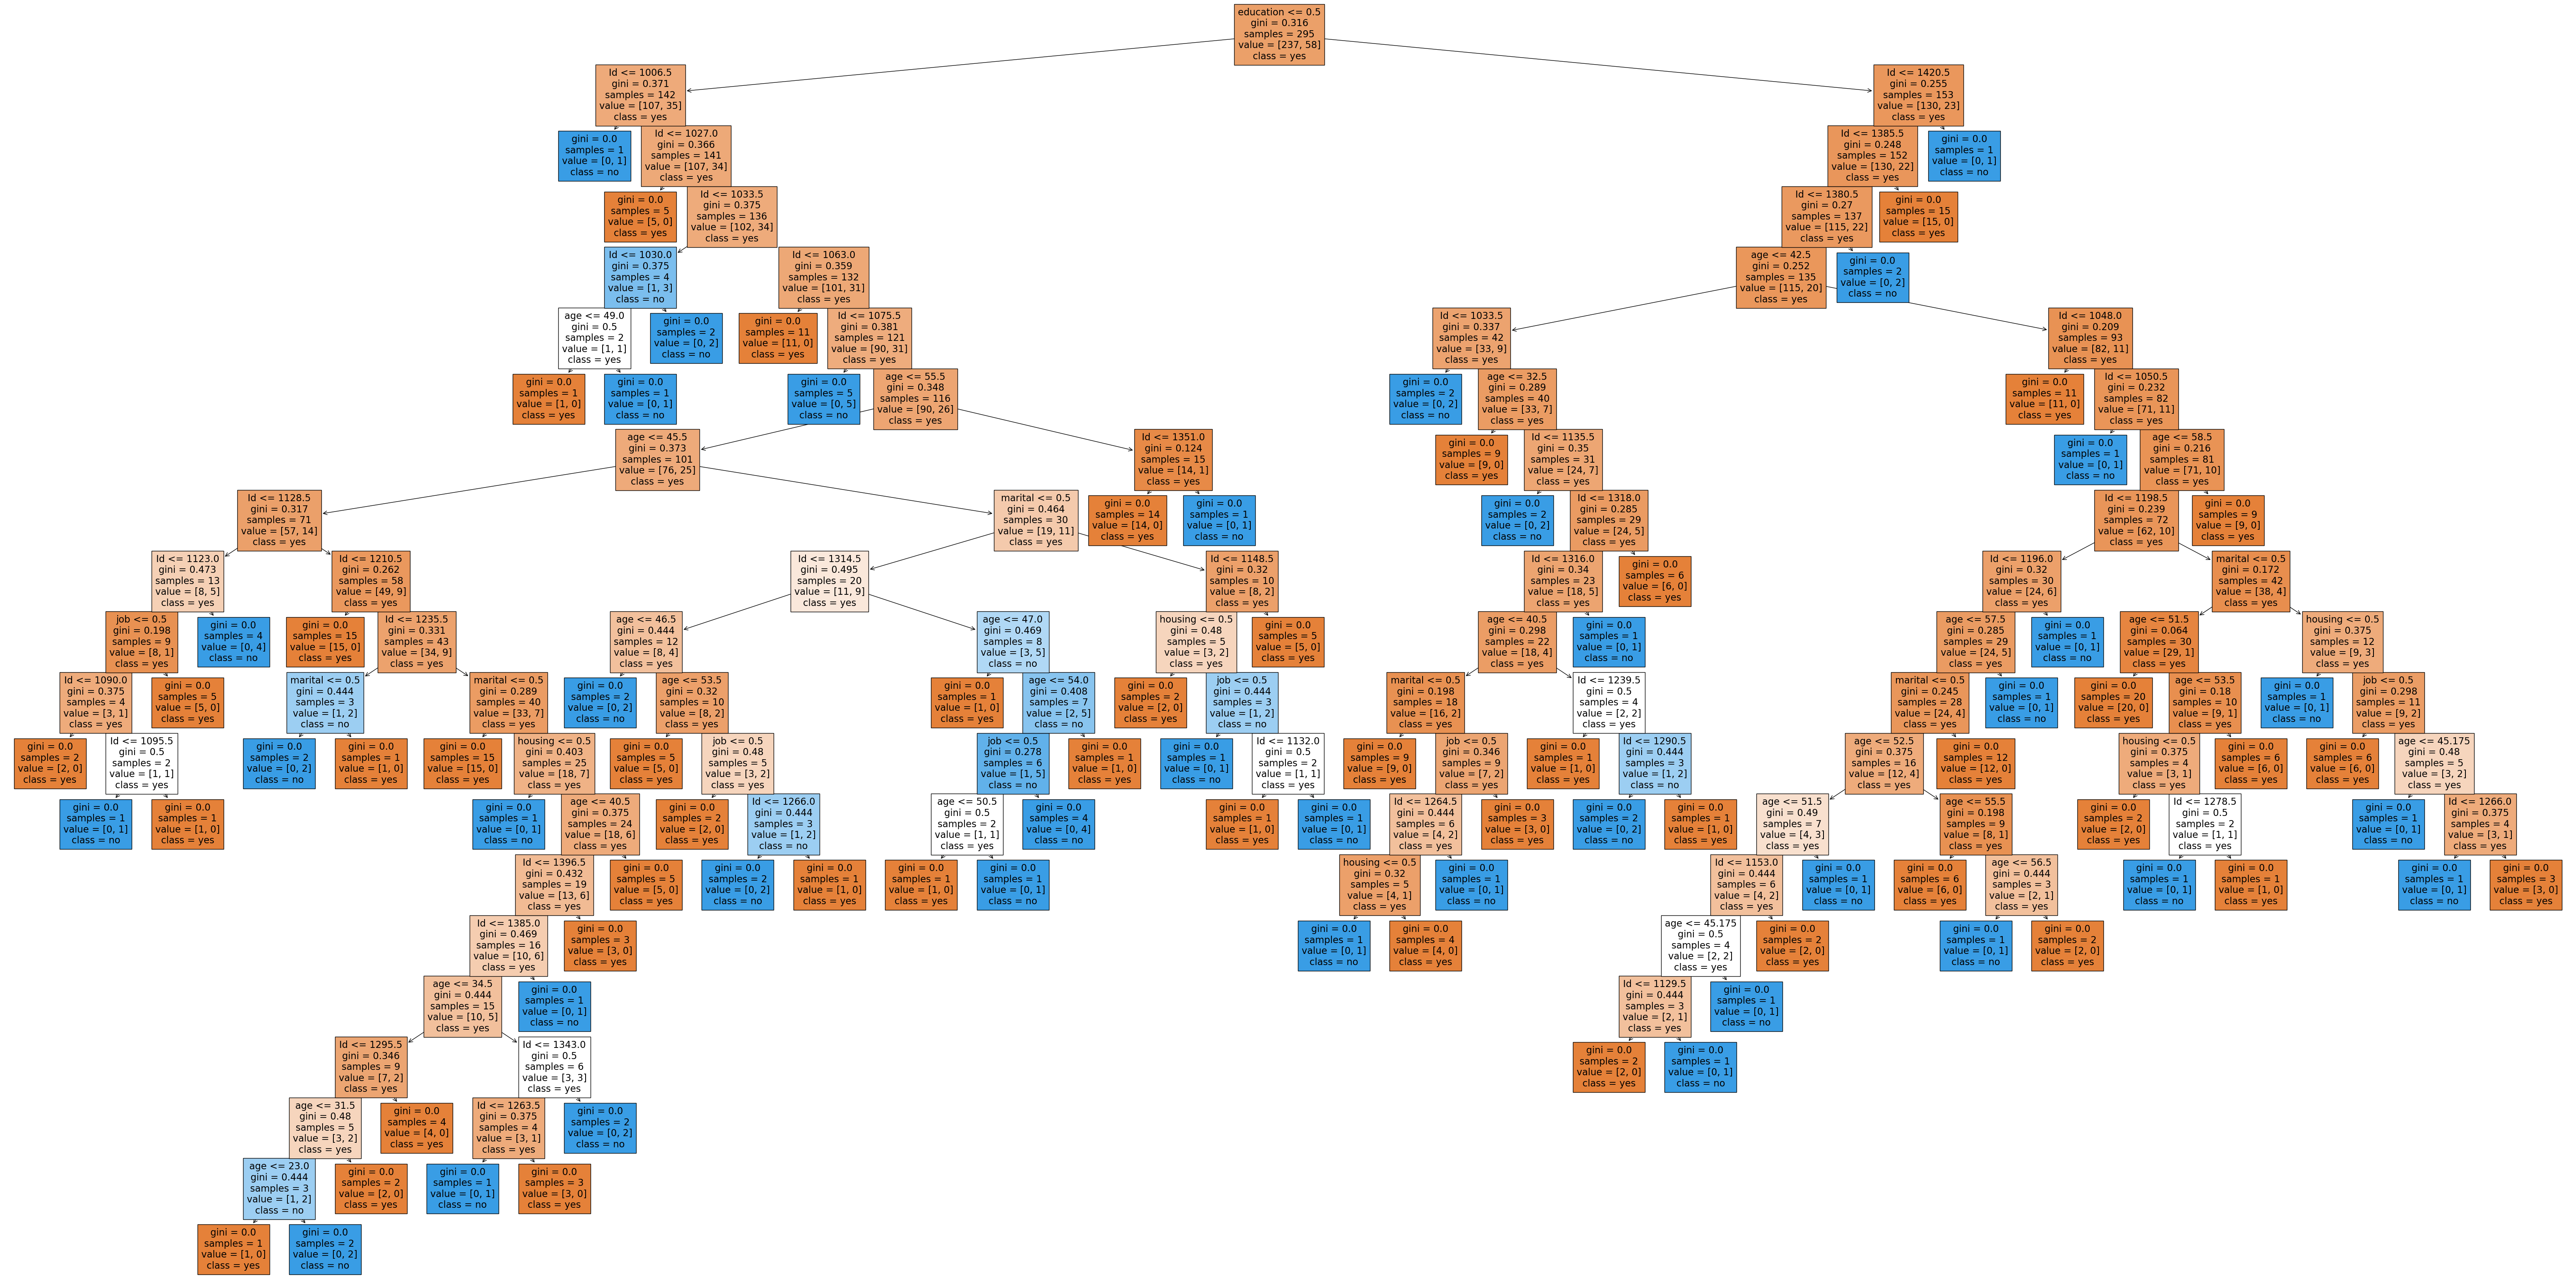

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import matplotlib.pyplot as plt

# Encode the target variable 'loan'
label_encoder=LabelEncoder()
new_df['loan']=label_encoder.fit_transform(new_df['loan'])

#split the data into features(x) and target(y)
X=new_df.drop('loan',axis=1)
y =new_df['loan']

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3 , random_state =0)

# Create the decision tree classifier
clf = DecisionTreeClassifier()

# Train the classifier
clf.fit(X_train, y_train)

plt.figure(figsize=(80,40))
tree.plot_tree(clf, feature_names=list(X.columns), class_names=['yes','no'], filled=True)
plt.show()

In [ ]:
# training the model on training set
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
# making predictions on the testing set
y_pred = gnb.predict(X_test)
accuracy = (y_pred == y_test).mean()
print("Accuracy: \n",accuracy)

Accuracy: 
 0.7322834645669292


In [ ]:
#Import svm model
from sklearn import svm

#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel  K(x, xi) = sum(x * xi)

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy: how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(y_test, y_pred))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(y_test, y_pred))

Accuracy: 0.7322834645669292
Precision: 0.0
Recall: 0.0


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
